https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html

https://www.kaggle.com/code/geekysaint/solving-mnist-using-pytorch

In [1]:
from torch import nn
from torch.nn.modules.module import register_module_forward_hook
from torchvision.datasets import MNIST, FashionMNIST
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
import torch
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import trange
from IPython.display import display, clear_output

## Solution 1 -- DONE

In [2]:
labels = ["T-Shirt","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle Boot"]
root = '~/DataScience/datasets/'
train_data = MNIST(root, download=True, transform=ToTensor(), train=True)
test_data = MNIST(root, download=True, transform=ToTensor(), train=False)

In [3]:
is_first_training_batch = False

@register_module_forward_hook
def forward_hook(layer, x: list[torch.Tensor], y: torch.Tensor) -> None:
    """This runs after inference of each layer in model's forward pass."""
    if is_first_training_batch and isinstance(layer, nn.ReLU):
        layer.output_means.append(y.mean().item())
        layer.output_variances.append(y.var().item())

In [4]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item()/ len(preds))

def relu():
    activation = nn.ReLU()
    activation.output_means = []
    activation.output_variances = []
    return activation

class MnistModule(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.hidden_layers = nn.ModuleList([
            nn.Linear(784, 256),
            relu(),
            nn.Linear(256, 128),
            relu(),
            nn.Linear(128, 64),
            relu()
        ])
        self.output_layer = nn.Linear(64, 10)
        self.is_first_training_batch = False

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = torch.flatten(x, start_dim=1)
        for layer in self.hidden_layers:
            x = layer(x)
        return self.output_layer(x)
    
    def validation_step(self, batch):
        images, labels = batch
        out = self(images)
        loss = nn.functional.cross_entropy(out, labels)
        acc = accuracy(out, labels)
        return {'val_loss':loss, 'val_acc': acc, 'out': out}
    
    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()
        return {'val_loss': epoch_loss.item(), 'val_acc' : epoch_acc.item()}
    
model = MnistModule()

In [5]:
batch_size = 128
train_loader = DataLoader(train_data, batch_size, shuffle = True)
val_loader = DataLoader(test_data, batch_size, shuffle = False)

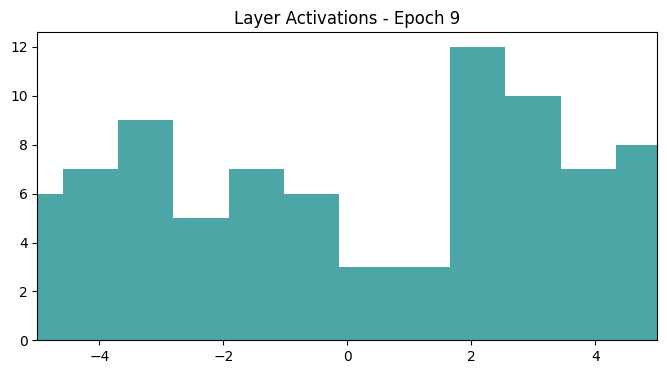

[{'val_loss': 0.3353109359741211, 'val_acc': 0.9010087251663208},
 {'val_loss': 0.20547060668468475, 'val_acc': 0.9385878443717957},
 {'val_loss': 0.14262232184410095, 'val_acc': 0.9572784900665283},
 {'val_loss': 0.12168817967176437, 'val_acc': 0.9634097814559937},
 {'val_loss': 0.09783388674259186, 'val_acc': 0.9709256291389465},
 {'val_loss': 0.08755912631750107, 'val_acc': 0.9730023741722107},
 {'val_loss': 0.08121342957019806, 'val_acc': 0.9755735993385315},
 {'val_loss': 0.08838088065385818, 'val_acc': 0.9730023741722107},
 {'val_loss': 0.07437972724437714, 'val_acc': 0.9778481125831604},
 {'val_loss': 0.08031757920980453, 'val_acc': 0.9766613841056824}]

In [6]:
def evaluate(model, val_loader) -> tuple[torch.Tensor, dict[str, float]]:
    outputs = [model.validation_step(batch) for batch in val_loader]
    metrics = model.validation_epoch_end(outputs)
    return outputs[-1]['out'], metrics

def fit(model, train_loader, val_loader, epochs: int, lr: float):
    global is_first_training_batch

    fig, ax = plt.subplots(figsize=(8, 4))
    history = []
    optimizer = torch.optim.SGD(model.parameters(), lr)
    for epoch in range(epochs):
        #print('Epoch', epoch)
        is_first_training_batch = True
        for batch in train_loader:
            images, labels = batch
            out = model(images)
            loss = nn.functional.cross_entropy(out, labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            is_first_training_batch = False

        out, metrics = evaluate(model, val_loader)
        history.append(metrics)
        #print("Epoch [{}], val_loss: {:.4f}, val_acc: {:.4f}".format(epoch, metrics['val_loss'], metrics['val_acc']))

        out = out.flatten().detach().cpu().numpy()
        ax.clear()
        ax.hist(out, bins=50, color='teal', alpha=0.7)
        ax.set_title(f"Layer Activations - Epoch {epoch}")
        ax.set_xlim(-5, 5)
        
        clear_output(wait=True)
        display(fig)            

    plt.close()
    return history

history = fit(model, train_loader, val_loader, epochs=10, lr=0.1)
history

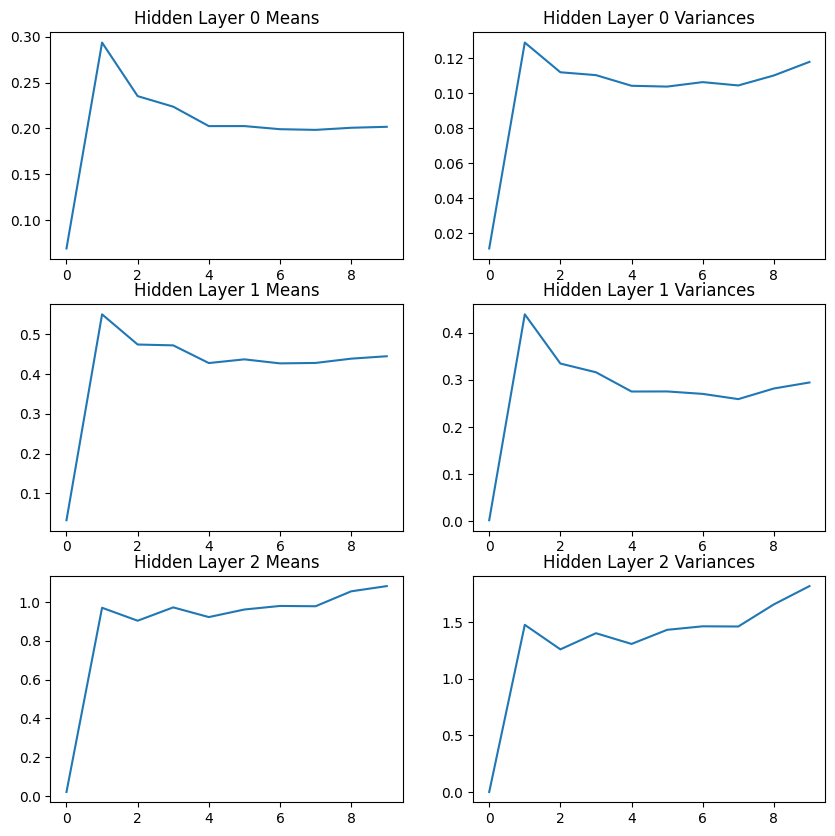

In [16]:
fig, axes = plt.subplots(3,2, figsize=(10,10))
for i in range(3):
    relu = model.hidden_layers[2*i + 1]
    axes[i,0].plot(np.arange(10), relu.output_means)
    axes[i,0].set_title(f'Hidden Layer {i} Means')

    axes[i,1].plot(np.arange(10), relu.output_variances)
    axes[i,1].set_title(f'Hidden Layer {i} Variances')

## Solution 4

In [8]:
# TODO

## Solution 6

In [9]:
# TODO

## Solution 8

In [10]:
# TODO

## Solution 10

In [11]:
# TODO

## Solution 12

In [12]:
# TODO

## Solution 14

In [13]:
# TODO

## Solution 15

In [14]:
# TODO